In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

folder_path = r"C:\Users\S Das\Downloads\archive (2)"
all_files = glob.glob(folder_path + r"\*.csv")

df = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)


C:\Users\S Das\AppData\Local\Temp\ipykernel_14508\2774630565.py:9: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)


In [5]:
df.columns.tolist()

['index',
 'Order ID',
 'Date',
 'Status',
 'Fulfilment',
 'Sales Channel ',
 'ship-service-level',
 'Style',
 'SKU',
 'Category',
 'Size',
 'ASIN',
 'Courier Status',
 'Qty',
 'currency',
 'Amount',
 'ship-city',
 'ship-state',
 'ship-postal-code',
 'ship-country',
 'promotion-ids',
 'B2B',
 'fulfilled-by',
 'Unnamed: 22',
 'Shiprocket',
 'Unnamed: 1',
 'INCREFF',
 'Recived Amount',
 'Expance',
 'Exp Amt',
 'DATE',
 'Months',
 'CUSTOMER',
 'PCS',
 'RATE',
 'GROSS AMT',
 'Sku',
 'Style Id',
 'Catalog',
 'Weight',
 'TP',
 'MRP Old',
 'Final MRP Old',
 'Ajio MRP',
 'Amazon MRP',
 'Amazon FBA MRP',
 'Flipkart MRP',
 'Limeroad MRP',
 'Myntra MRP',
 'Paytm MRP',
 'Snapdeal MRP',
 'TP 1',
 'TP 2',
 'SKU Code',
 'Design No.',
 'Stock',
 'Color']

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.fillna(0, inplace=True)

In [8]:
# total revenue by qty and amount

df['Revenue'] = df['Qty'] * df['Amount']
df['Total Revenue'] = df['Revenue'].sum()

In [9]:
# avg order value 

df['Total Orders'] = df['Order ID'].nunique()
df['AOV'] = df['Total Revenue'] / df['Total Orders']

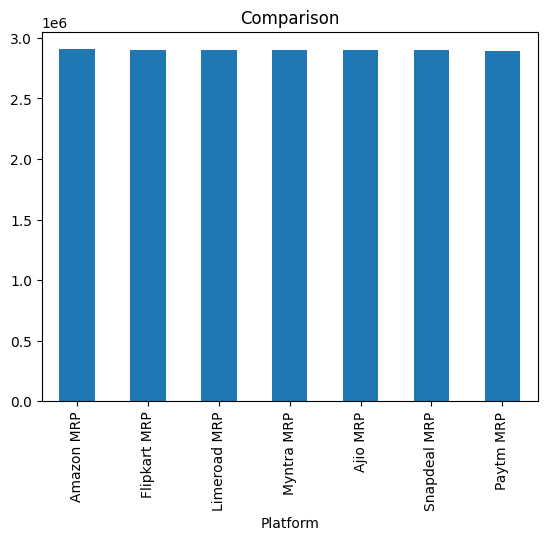

In [10]:
# data compare among coapnies with MRP

folder_path = r"C:\Users\S Das\Downloads\archive (2)\P  L March 2021.csv"
df = pd.concat([pd.read_csv(f) for f in glob.glob(folder_path)], ignore_index=True)

# platforms data
platforms = ['Amazon MRP', 'Flipkart MRP', 'Ajio MRP', 'Myntra MRP', 'Snapdeal MRP', 'Limeroad MRP', 'Paytm MRP']

# transfroms general data into numeric data 
for col in platforms:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# melted it for long values
melted_df = df[platforms].melt(var_name='Platform', value_name='MRP')

# dropping NAN values
melted_df = melted_df.dropna()

summary = melted_df.groupby('Platform')['MRP'].sum().sort_values(ascending=False)

summary.plot(kind='bar')
plt.title('Comparison')

plt.show()

C:\Users\S Das\AppData\Local\Temp\ipykernel_14508\911966818.py:4: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\S Das\Downloads\archive (2)\Amazon Sale Report.csv")


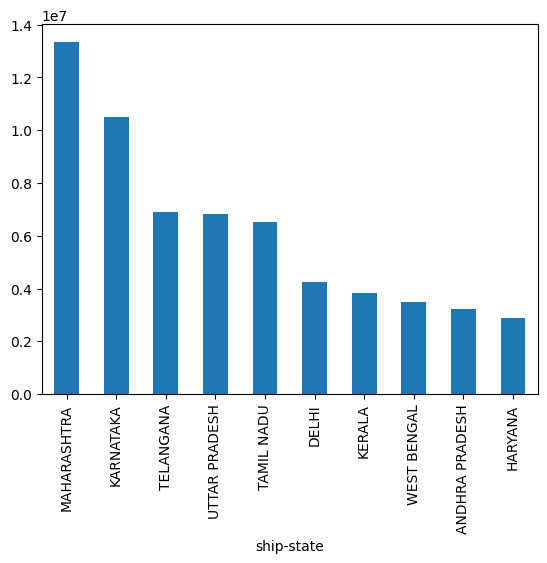

In [11]:
# chart for sales in ship states or ship country

# load reqs
df = pd.read_csv(r"C:\Users\S Das\Downloads\archive (2)\Amazon Sale Report.csv")

# strings splits the spaces
df.columns = df.columns.str.strip()

# numeral transforms
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

# mapping the chart in map plot
map_chart = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

In [12]:
df.columns.tolist()

['index',
 'Order ID',
 'Date',
 'Status',
 'Fulfilment',
 'Sales Channel',
 'ship-service-level',
 'Style',
 'SKU',
 'Category',
 'Size',
 'ASIN',
 'Courier Status',
 'Qty',
 'currency',
 'Amount',
 'ship-city',
 'ship-state',
 'ship-postal-code',
 'ship-country',
 'promotion-ids',
 'B2B',
 'fulfilled-by',
 'Unnamed: 22']

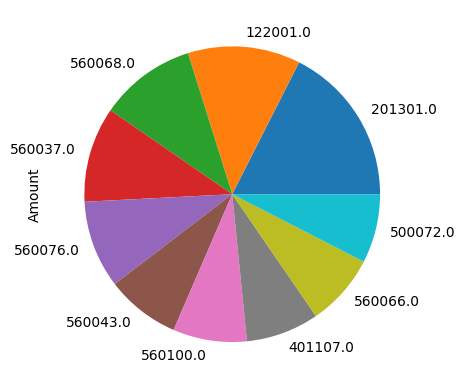

In [13]:
df.columns = df.columns.str.strip()

df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

chart = df.groupby('ship-postal-code')['Amount'].sum().sort_values(ascending=False).head(10).plot(kind='pie')

In [14]:
import pandas as pd

folder_path = r"C:\Users\S Das\Downloads\archive (2)\P  L March 2021.csv"
df = pd.concat([pd.read_csv(f) for f in glob.glob(folder_path)], ignore_index=True)

# Load files
df_amount = pd.read_csv(r"C:\Users\S Das\Downloads\archive (2)\Amazon Sale Report.csv", low_memory=False)
df_expense = pd.read_csv(r"C:\Users\S Das\Downloads\archive (2)\Expense IIGF.csv")

# drop useless cols and ignore errors 
df_amount = df_amount.drop(columns=['unnamed: 22'], errors='ignore')

# Convert both columns to numeric (optional: errors='coerce' will set bad values as NaN)
df_amount['Amount'] = pd.to_numeric(df_amount['Amount'], errors='coerce')
df_expense['Exp Amt'] = pd.to_numeric(df_expense['Exp Amt'], errors='coerce')

# Now compute profit
df['Profit'] = df_amount['Amount'] - df_expense['Exp Amt']


In [ ]:
df.fillna(0).head(10)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load the CSV
df = pd.read_csv(r"C:\Users\S Das\Downloads\archive (2)\Amazon Sale Report.csv", low_memory=False)

# Clean and convert 'Amount' to numeric if needed
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
df = df.dropna(subset=['SKU', 'Amount', 'Order ID'])

# Create a pivot table
hmap_data = df.pivot_table(
    index='SKU',
    columns='Amount',
    values='Order ID',
    aggfunc='count',
    fill_value=0
)

# Due to high cardinality, limit the pivot to top N values
hmap_data = hmap_data.iloc[:20, :20]  # Adjust as needed for clarity

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(hmap_data, cmap='YlGnBu', annot=False, linewidths=0.5)
plt.xlabel('Amount')
plt.ylabel('SKU')
plt.title('Order Frequency by SKU and Amount')
plt.tight_layout()
plt.show()


In [1]:
import os
os.getcwd()



'C:\\Users\\S Das\\PycharmProjects\\PythonProject'